# Brain Tumor Classification with Deep Learning (For Beginners! 🚀)

Welcome! In this notebook, we will build an Artificial Intelligence (AI) model capable of classifying different types of Brain Tumors from MRI images.

### What are we going to do?
1. **Load and Prepare our Data**: Computers need data organized in a specific way to learn.
2. **Preprocess & Augment**: We will resize our images and create slightly altered versions (like flipping) to help our model generalize better.
3. **Build the Brain (Model Architecture)**: We will use a highly advanced, pre-existing structure called `EfficientNetB0` (Transfer Learning) to help us out.
4. **Train the Model**: We'll teach the AI using our images.
5. **Evaluate & Visualize**: We'll see how smart our model actually is by showing it MRI scans it has never seen before!

Let's get started by importing the necessary Python libraries!


In [2]:
# ---------------------------------------------------------
# IMPORTING LIBRARIES
# ---------------------------------------------------------
import os                     # To interact with the operating system (e.g., reading files/folders)
import shutil                 # To copy/move files around
import random                 # To randomly shuffle our data
import numpy as np            # For numerical operations and arrays
import matplotlib.pyplot as plt # For drawing graphs and visualizing images
import seaborn as sns         # To make beautiful visualizations, like Confusion Matrices

# TensorFlow and Keras are the core libraries for building Deep Learning AI models
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

# We set fixed 'seeds' here. This ensures that every time we run this code, the random
# shuffling and calculations produce the exact same result (Reproducibility).
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Dataset Preparation 📁

Our data consists of MRI images divided into 44 folders representing 44 different classes (types) of conditions.

### The Problem:
Usually, when training an AI, you need **three** sets of data:
1. **Training Set (70%):** The study material. The AI uses this to learn.
2. **Validation Set (15%):** The practice tests. The AI uses this to tune itself during training.
3. **Testing Set (15%):** The final exam. Used *after* the AI finishes learning to see its true performance.

Currently, all our images are mixed together in `data/brain_tumor_data`.
In the code cell below, we create a function that automatically copies and sorts these images into three new folders (`train`, `val`, and `test`)!

In [8]:
# ---------------------------------------------------------
# PATH CONFIGURATIONS
# ---------------------------------------------------------
# Here we define the folder paths.
ORIGINAL_DATA_DIR = 'data/brain_tumor_data' # Where your images currently live
SPLIT_DATA_DIR = 'data_split/brain_tumor_data'               # The main newly created folder to hold our 3 splits

# Inside the 'data_split' directory, we will create these 3 new folders:
TRAIN_DIR = os.path.join(SPLIT_DATA_DIR, 'train')
VAL_DIR = os.path.join(SPLIT_DATA_DIR, 'val')
TEST_DIR = os.path.join(SPLIT_DATA_DIR, 'test')

In [9]:
# ---------------------------------------------------------
# AUTOMATIC DATA SPLITTING FUNCTION
# ---------------------------------------------------------
def create_dataset_splits(source_dir, train_dir, val_dir, test_dir, split_ratios=(0.7, 0.15, 0.15)):
    '''
    This function reads images from a source directory, shuffles them, and divides them into Train, Validation, and Test directories.
    '''
    if not os.path.exists(source_dir):
        print(f"Error: Could not find the source folder: {source_dir}")
        return
        
    # Get a list of all 44 class folders inside the source directory
    classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]
    print(f"Discovered {len(classes)} classes of tumors.\nSplitting dataset into {split_ratios} (Train, Val, Test)...\n")
    
    # Loop through each of the 44 diseases
    for class_name in classes:
        # 1. Create sub-folders for this specific disease in train, val, and test.
        #    e.g. data_split/train/Astrocitoma_T1
        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)
        
        # 2. Get a list of every image file for this specific disease
        class_folder_path = os.path.join(source_dir, class_name)
        images = os.listdir(class_folder_path)
        
        # 3. Shuffle the images so the AI doesn't memorize their order
        random.shuffle(images)
        
        # 4. Calculate exactly how many images correspond to 70%, 15%, and 15%
        total_images = len(images)
        train_cut = int(total_images * split_ratios[0])
        val_cut = train_cut + int(total_images * split_ratios[1])
        
        # 5. Slice the list of images based on our calculations
        train_images = images[:train_cut]
        val_images = images[train_cut:val_cut]
        test_images = images[val_cut:]
        
        # 6. Finally, loop through these sliced lists, and copy the actual .jpg/.png files over
        for img in train_images:
            shutil.copy(os.path.join(class_folder_path, img), os.path.join(train_dir, class_name, img))
        for img in val_images:
            shutil.copy(os.path.join(class_folder_path, img), os.path.join(val_dir, class_name, img))
        for img in test_images:
            shutil.copy(os.path.join(class_folder_path, img), os.path.join(test_dir, class_name, img))
            
    print("✅ Success! Images have been split into the robust 'data_split/' directory.")

# -> RUN THE SPLITTER
# It might take a minute depending on how many thousands of files there are!
create_dataset_splits(ORIGINAL_DATA_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR)

Discovered 44 classes of tumors.
Splitting dataset into (0.7, 0.15, 0.15) (Train, Val, Test)...

✅ Success! Images have been split into the robust 'data_split/' directory.


## 2. Data Preprocessing & Augmentation 🖼️

Now that our data is separated into Train, Validation, and Test folders, we can't just throw raw images into the AI. We need to **Pre-process** them.

### What must be done?
1. **Resizing:** Images come in all shapes. We must force them to all be `224x224` pixels because our AI Architecture expects uniform squares.
2. **Normalization:** Image pixels are numbered 0 to 255 (0 is black, 255 is white). Neural networks prefer numbers between 0.0 and 1.0! So, we will divide all pixels by 255 `(rescale=1./255)`.

### Data Augmentation (Training ONLY)
To prevent our AI from "memorizing" specific training images (Overfitting), we dynamically alter the training images slightly before feeding them in. We rotate them, stretch them, and flip them! The AI sees a slightly different variation every time, making it smarter!

> We **do NOT** augment the Validation or Test Sets. We want to test the model on normal, un-altered images.

In [ ]:
# We define a standard, squared target size
IMG_WIDTH, IMG_HEIGHT = 224, 224
IMG_SIZE = (IMG_WIDTH, IMG_HEIGHT)

# BATCH SIZE: How many images the AI processes at once before updating its "memory".
# 32 is standard. If your computer crashes running out of memory, lower this to 16.
BATCH_SIZE = 16

# -------------------------------------------------------------
# DEFINING THE "GENERATORS"
# -------------------------------------------------------------

# 1. Training Generator (Includes Data Augmentation!)
train_datagen = ImageDataGenerator(
    rescale=1./255,               # Normalize pixel values (0-255 -> 0.0-1.0)
    rotation_range=15,            # Randomly rotate image laterally by up to 15 degrees
    width_shift_range=0.1,        # Shift image horizontally by 10%
    height_shift_range=0.1,       # Shift image vertically by 10%
    shear_range=0.1,              # Slant/distort the image
    brightness_range=[0.9, 1.1],  # Randomly darken or lighten by 10%
    horizontal_flip=True          # Flips the MRI scan (Left becomes right)
)

# 2. Validation & Testing Generator (NO Augmentation, ONLY Normalization)
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [13]:
from IPython.display import display, HTML

# -------------------------------------------------------------
# LOADING THE IMAGES FROM FOLDERS INTO MEMORY
# -------------------------------------------------------------
print("Preparing Data Batches:\n")

# Connect the Train Generator to the 'train' folder
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # We use 'categorical' because we have 44 mutually-exclusive diseases
)

# Connect the Val Generator to the 'val' folder
val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False              # Do not shuffle validation, keep it consistent for plotting
)

# Connect the Test Generator to the 'test' folder
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False              # Do not shuffle testing, so we can perfectly compare True vs Predicted Labels later
)

# Extract important variables to use later
NUM_CLASSES = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())

print(f"\n ✅ We discovered {NUM_CLASSES} distinct Brain Tumor classes!")

Preparing Data Batches:

Found 3116 images belonging to 44 classes.
Found 649 images belonging to 44 classes.
Found 713 images belonging to 44 classes.

 ✅ We discovered 44 distinct Brain Tumor classes!


## 3. The Brain (Model Architecture) 🧠

Writing an AI from scratch to detect tumors takes millions of images and huge computation. Instead, we use **Transfer Learning**.

We load `EfficientNetB0`—an incredible image classification AI built by Google that has *already* learned how to "see" shapes, edges, and objects by looking at 14 million daily-life images (the ImageNet dataset).

### Creating our custom Tumor Detective:
1. Load `EfficientNetB0` without its "head" (its original ability to classify 1,000 random objects like dogs, cars, TVs).
2. "Freeze" the body, so we don't accidentally erase its ability to physically "see" edges and textures.
3. Add our own custom "Head" (the Dense layers) responsible for classifying the 44 specific Brain Tumors via the `Softmax` function!

Let's build it!

In [ ]:
# 1. Provide the pre-trained EfficientNetB0 BASE
base_model = EfficientNetB0(
    weights='imagenet',          # Use the intelligence learned from Google's ImageNet dataset
    include_top=False,           # Remove the original "head" of the AI
    input_shape=(224, 224, 3)    # Give it our 224x224 RGB Image constraints
)

# 2. Freeze the base layers so we don't ruin what it already knows
base_model.trainable = False

# 3. Stack on our custom Brain Tumor Classification Layers!
x = base_model.output

# Reduce the overwhelming 3D geometry of the base output into a neat 1D array
x = GlobalAveragePooling2D()(x)

# Dropout turns off 30% of neurons randomly. This forces the remaining neurons to work harder!
# (It dramatically reduces 'Overfitting' - when an AI memorizes data instead of actually learning).
x = Dropout(0.3)(x)

# Finally, our "Head" logic. A Dense layer with 44 nodes (One for each disease).
# Softmax ensures that all 44 probabilities add up to 100%. "I am 80% sure this is cancer."
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# --------------------------
# COMPILE AND BIND THE MODEL
# --------------------------
# We merge the Google Base with our Custom Head:
model = Model(inputs=base_model.input, outputs=predictions)

# Compiling configures HOW the AI learns.
model.compile(
    optimizer=Adam(learning_rate=0.0001),  # The Adam Optimizer automatically tunes the learning math formulas!
    loss='categorical_crossentropy',      # The formula to calculate exactly "how wrong" the current AI guess is
    metrics=['accuracy']                  # We want human-readable accuracy percentages
)

# Print a block showing the AI's internal physical structure
model.summary()

2026-03-03 02:42:22.952324: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 14s 1us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,105,935 (15.66 MB)

 Trainable params: 56,364 (220.17 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 4. Training (Teaching the AI) 🎓

Now we enter the most computationally heavy phase.

We set `EPOCHS = 30`. One "Epoch" means the AI will look at every single image in the Train set exactly one time.

### Smart Interventions (Callbacks):
To ensure perfection, we add 3 smart tools that watch the AI while it trains:
1. `EarlyStopping`: If the Validation Loss stops improving for 5 epochs... the AI has stopped learning. Auto-Stop the training to save time!
2. `ReduceLROnPlateau`: Sometimes the learning math (gradient descent) gets "stuck". This reduces the learning-rate jumps making learning more precise when stalled.
3. `ModelCheckpoint`: Behind the scenes, we automatically save the physical `.h5` model file to the hard drive on the exact epoch where it scored the best!

In [16]:
EPOCHS = 30

# Where we will save the finalized trained AI model
os.makedirs('../inference/models', exist_ok=True)
MODEL_SAVE_PATH = '../inference/models/brain_tumor_efficientnetb0.h5'

# 1. Early Stopping Rule
early_stopping = EarlyStopping(
    monitor='val_loss',         # Watch how 'wrong' the Validation test is
    patience=5,                 # Wait 5 epochs before giving up
    restore_best_weights=True,  # Ensure our final model rolls-back to its best Epoch!
    verbose=1
)

# 2. Modify Learning Speed Rule
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,                 # If stuck, divide the learning speed (jump size) by 5.
    patience=3,                 # Do this if it gets stuck for 3 epochs
    min_lr=1e-6,                # Don't let it slow down endlessly. Bottom threshold.
    verbose=1
)

# 3. Model Saver
model_checkpoint = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,        # ONLY Overwrite the file if THIS epoch beats the previous high-score
    verbose=1
)

print("Starting to train the AI... This will take some time! Grab a coffee ☕")

# --> TEACH THE MODEL <--
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)

print(f"\n✅ Training concluded! The best version was safely deposited at {MODEL_SAVE_PATH}")

Starting to train the AI... This will take some time! Grab a coffee ☕
Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 732ms/step - accuracy: 0.0613 - loss: 3.6000
Epoch 1: val_loss improved from None to 3.47874, saving model to ../inference/models/brain_tumor_efficientnetb0.h5



Epoch 1: finished saving model to ../inference/models/brain_tumor_efficientnetb0.h5
98/98 ━━━━━━━━━━━━━━━━━━━━ 100s 929ms/step - accuracy: 0.0597 - loss: 3.5642 - val_accuracy: 0.0847 - val_loss: 3.4787 - learning_rate: 0.0010
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 747ms/step - accuracy: 0.0645 - loss: 3.5485
Epoch 2: val_loss did not improve from 3.47874
98/98 ━━━━━━━━━━━━━━━━━━━━ 88s 901ms/step - accuracy: 0.0696 - loss: 3.5473 - val_accuracy: 0.0847 - val_loss: 3.4947 - learning_rate: 0.0010
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.0721 - loss: 3.5201
Epoch 3: val_loss did not improve from 3.47874
98/98 ━━━━━━━━━━━━━━━━━━━━ 89s 910ms/step - accuracy: 0.0773 - loss: 3.5291 - val_accuracy: 0.0570 - val_loss: 3.5175 - learning_rate: 0.0010
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 770ms/step - accuracy: 0.0681 - loss: 3.5545
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 4: val_loss did not improve from 3.47874
98/98 ━━━━━


Epoch 5: finished saving model to ../inference/models/brain_tumor_efficientnetb0.h5
98/98 ━━━━━━━━━━━━━━━━━━━━ 93s 945ms/step - accuracy: 0.0735 - loss: 3.5086 - val_accuracy: 0.0847 - val_loss: 3.4590 - learning_rate: 2.0000e-04
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.0737 - loss: 3.5102
Epoch 6: val_loss did not improve from 3.45903
98/98 ━━━━━━━━━━━━━━━━━━━━ 92s 936ms/step - accuracy: 0.0767 - loss: 3.4971 - val_accuracy: 0.0847 - val_loss: 3.4595 - learning_rate: 2.0000e-04
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.0811 - loss: 3.5021
Epoch 7: val_loss did not improve from 3.45903
98/98 ━━━━━━━━━━━━━━━━━━━━ 85s 869ms/step - accuracy: 0.0786 - loss: 3.5029 - val_accuracy: 0.0847 - val_loss: 3.4591 - learning_rate: 2.0000e-04
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 732ms/step - accuracy: 0.0762 - loss: 3.4992
Epoch 8: val_loss improved from 3.45903 to 3.45824, saving model to ../inference/models/brain_tumor_efficientnetb0.h5



Epoch 8: finished saving model to ../inference/models/brain_tumor_efficientnetb0.h5
98/98 ━━━━━━━━━━━━━━━━━━━━ 88s 902ms/step - accuracy: 0.0757 - loss: 3.5023 - val_accuracy: 0.0847 - val_loss: 3.4582 - learning_rate: 2.0000e-04
Epoch 9/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 821ms/step - accuracy: 0.0725 - loss: 3.5042
Epoch 9: val_loss did not improve from 3.45824
98/98 ━━━━━━━━━━━━━━━━━━━━ 97s 988ms/step - accuracy: 0.0745 - loss: 3.4934 - val_accuracy: 0.0847 - val_loss: 3.4592 - learning_rate: 2.0000e-04
Epoch 10/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.0823 - loss: 3.4921
Epoch 10: val_loss did not improve from 3.45824
98/98 ━━━━━━━━━━━━━━━━━━━━ 92s 932ms/step - accuracy: 0.0806 - loss: 3.4995 - val_accuracy: 0.0847 - val_loss: 3.4586 - learning_rate: 2.0000e-04
Epoch 11/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - accuracy: 0.0860 - loss: 3.4802
Epoch 11: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.

Epoch 11: val_loss did not improve from 3.4


Epoch 12: finished saving model to ../inference/models/brain_tumor_efficientnetb0.h5
98/98 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.0677 - loss: 3.4959 - val_accuracy: 0.0847 - val_loss: 3.4572 - learning_rate: 4.0000e-05
Epoch 13/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 804ms/step - accuracy: 0.0764 - loss: 3.5026
Epoch 13: val_loss improved from 3.45722 to 3.45640, saving model to ../inference/models/brain_tumor_efficientnetb0.h5



Epoch 13: finished saving model to ../inference/models/brain_tumor_efficientnetb0.h5
98/98 ━━━━━━━━━━━━━━━━━━━━ 96s 980ms/step - accuracy: 0.0751 - loss: 3.4893 - val_accuracy: 0.0847 - val_loss: 3.4564 - learning_rate: 4.0000e-05
Epoch 14/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.0778 - loss: 3.4818
Epoch 14: val_loss improved from 3.45640 to 3.45612, saving model to ../inference/models/brain_tumor_efficientnetb0.h5



Epoch 14: finished saving model to ../inference/models/brain_tumor_efficientnetb0.h5
98/98 ━━━━━━━━━━━━━━━━━━━━ 96s 973ms/step - accuracy: 0.0783 - loss: 3.4916 - val_accuracy: 0.0847 - val_loss: 3.4561 - learning_rate: 4.0000e-05
Epoch 15/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.0829 - loss: 3.4907
Epoch 15: val_loss did not improve from 3.45612
98/98 ━━━━━━━━━━━━━━━━━━━━ 95s 966ms/step - accuracy: 0.0806 - loss: 3.4898 - val_accuracy: 0.0847 - val_loss: 3.4561 - learning_rate: 4.0000e-05
Epoch 16/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - accuracy: 0.0867 - loss: 3.4667
Epoch 16: val_loss improved from 3.45612 to 3.45603, saving model to ../inference/models/brain_tumor_efficientnetb0.h5



Epoch 16: finished saving model to ../inference/models/brain_tumor_efficientnetb0.h5
98/98 ━━━━━━━━━━━━━━━━━━━━ 97s 988ms/step - accuracy: 0.0783 - loss: 3.4853 - val_accuracy: 0.0847 - val_loss: 3.4560 - learning_rate: 4.0000e-05
Epoch 17/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 889ms/step - accuracy: 0.0780 - loss: 3.4999
Epoch 17: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.

Epoch 17: val_loss did not improve from 3.45603
98/98 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.0793 - loss: 3.4964 - val_accuracy: 0.0847 - val_loss: 3.4562 - learning_rate: 4.0000e-05
Epoch 18/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 894ms/step - accuracy: 0.0730 - loss: 3.4958
Epoch 18: val_loss did not improve from 3.45603
98/98 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.0741 - loss: 3.4941 - val_accuracy: 0.0847 - val_loss: 3.4561 - learning_rate: 8.0000e-06
Epoch 19/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0867 - loss: 3.5007
Epoch 19: val_loss did not improve from 3.45603


### 4B. Visualizing the Learning Curve 📈
We stored every metric during training into the `history` variable. Let's make some graphs using `matplotlib` to visually see how the model got smarter over time.

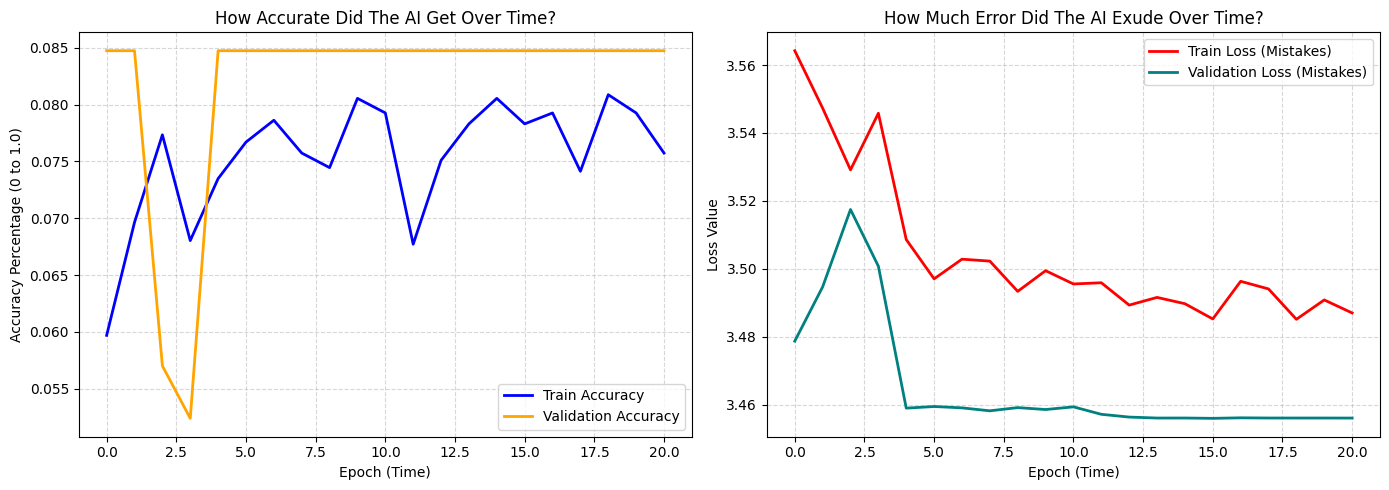

In [17]:
# Extract our learning data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(14, 5))

# --- GRAPH 1: ACCURACY ---
# You want both these lines to go UP towards 1.0 (100%)
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy', linewidth=2, color='blue')
plt.plot(val_acc, label='Validation Accuracy', linewidth=2, color='orange')
plt.title('How Accurate Did The AI Get Over Time?')
plt.xlabel('Epoch (Time)')
plt.ylabel('Accuracy Percentage (0 to 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# --- GRAPH 2: LOSS (ERRORS/MISTAKES) ---
# You want both these lines to go DOWN towards 0 (Zero Mistakes)
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss (Mistakes)', linewidth=2, color='red')
plt.plot(val_loss, label='Validation Loss (Mistakes)', linewidth=2, color='teal')
plt.title('How Much Error Did The AI Exude Over Time?')
plt.xlabel('Epoch (Time)')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Evaluation & Final Testing 💯

The AI is trained! BUT, is it actually smart?
We will unleash the finalized model on the `Test Dataset` (The 15% of images kept totally hidden away in the `data_split/test/` folder).

It has **NEVER** seen these images before. We will grade the exam!

In [18]:
# Run the final evaluation against the unseen truth
print("Grading the Final Exam...\n")

test_loss, test_acc = model.evaluate(test_generator)

print(f"🎯 Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"📉 Final Test Loss/Error: {test_loss:.4f}")

Grading the Final Exam...

23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 805ms/step - accuracy: 0.0785 - loss: 3.5116
🎯 Final Test Accuracy: 7.85%
📉 Final Test Loss/Error: 3.5116


### 5B. The Confusion Matrix and Deep Metrics

A percentage isn't always enough. Did it perform worse on `Astrocitoma` than `Meningioma`? Let's predict all test images one-by-one, store the answers, and create an analytical grid (The Confusion Matrix).

23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step 
----------- PREDICTION TEXT REPORT -----------
                        precision    recall  f1-score   support

        Astrocitoma T1       0.00      0.00      0.00        27
      Astrocitoma T1C+       0.00      0.00      0.00        36
        Astrocitoma T2       0.00      0.00      0.00        27
          Carcinoma T1       0.00      0.00      0.00        11
        Carcinoma T1C+       0.00      0.00      0.00        18
          Carcinoma T2       0.00      0.00      0.00        12
         Ependimoma T1       0.00      0.00      0.00         8
       Ependimoma T1C+       0.00      0.00      0.00         8
         Ependimoma T2       0.00      0.00      0.00        10
      Ganglioglioma T1       0.00      0.00      0.00         3
    Ganglioglioma T1C+       0.00      0.00      0.00         4
      Ganglioglioma T2       0.00      0.00      0.00         4
          Germinoma T1       0.00      0.00      0.00         5
        Germinom

/home/ab-mehdi/development/radiological-platform/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ab-mehdi/development/radiological-platform/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ab-mehdi/development/radiological-platform/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

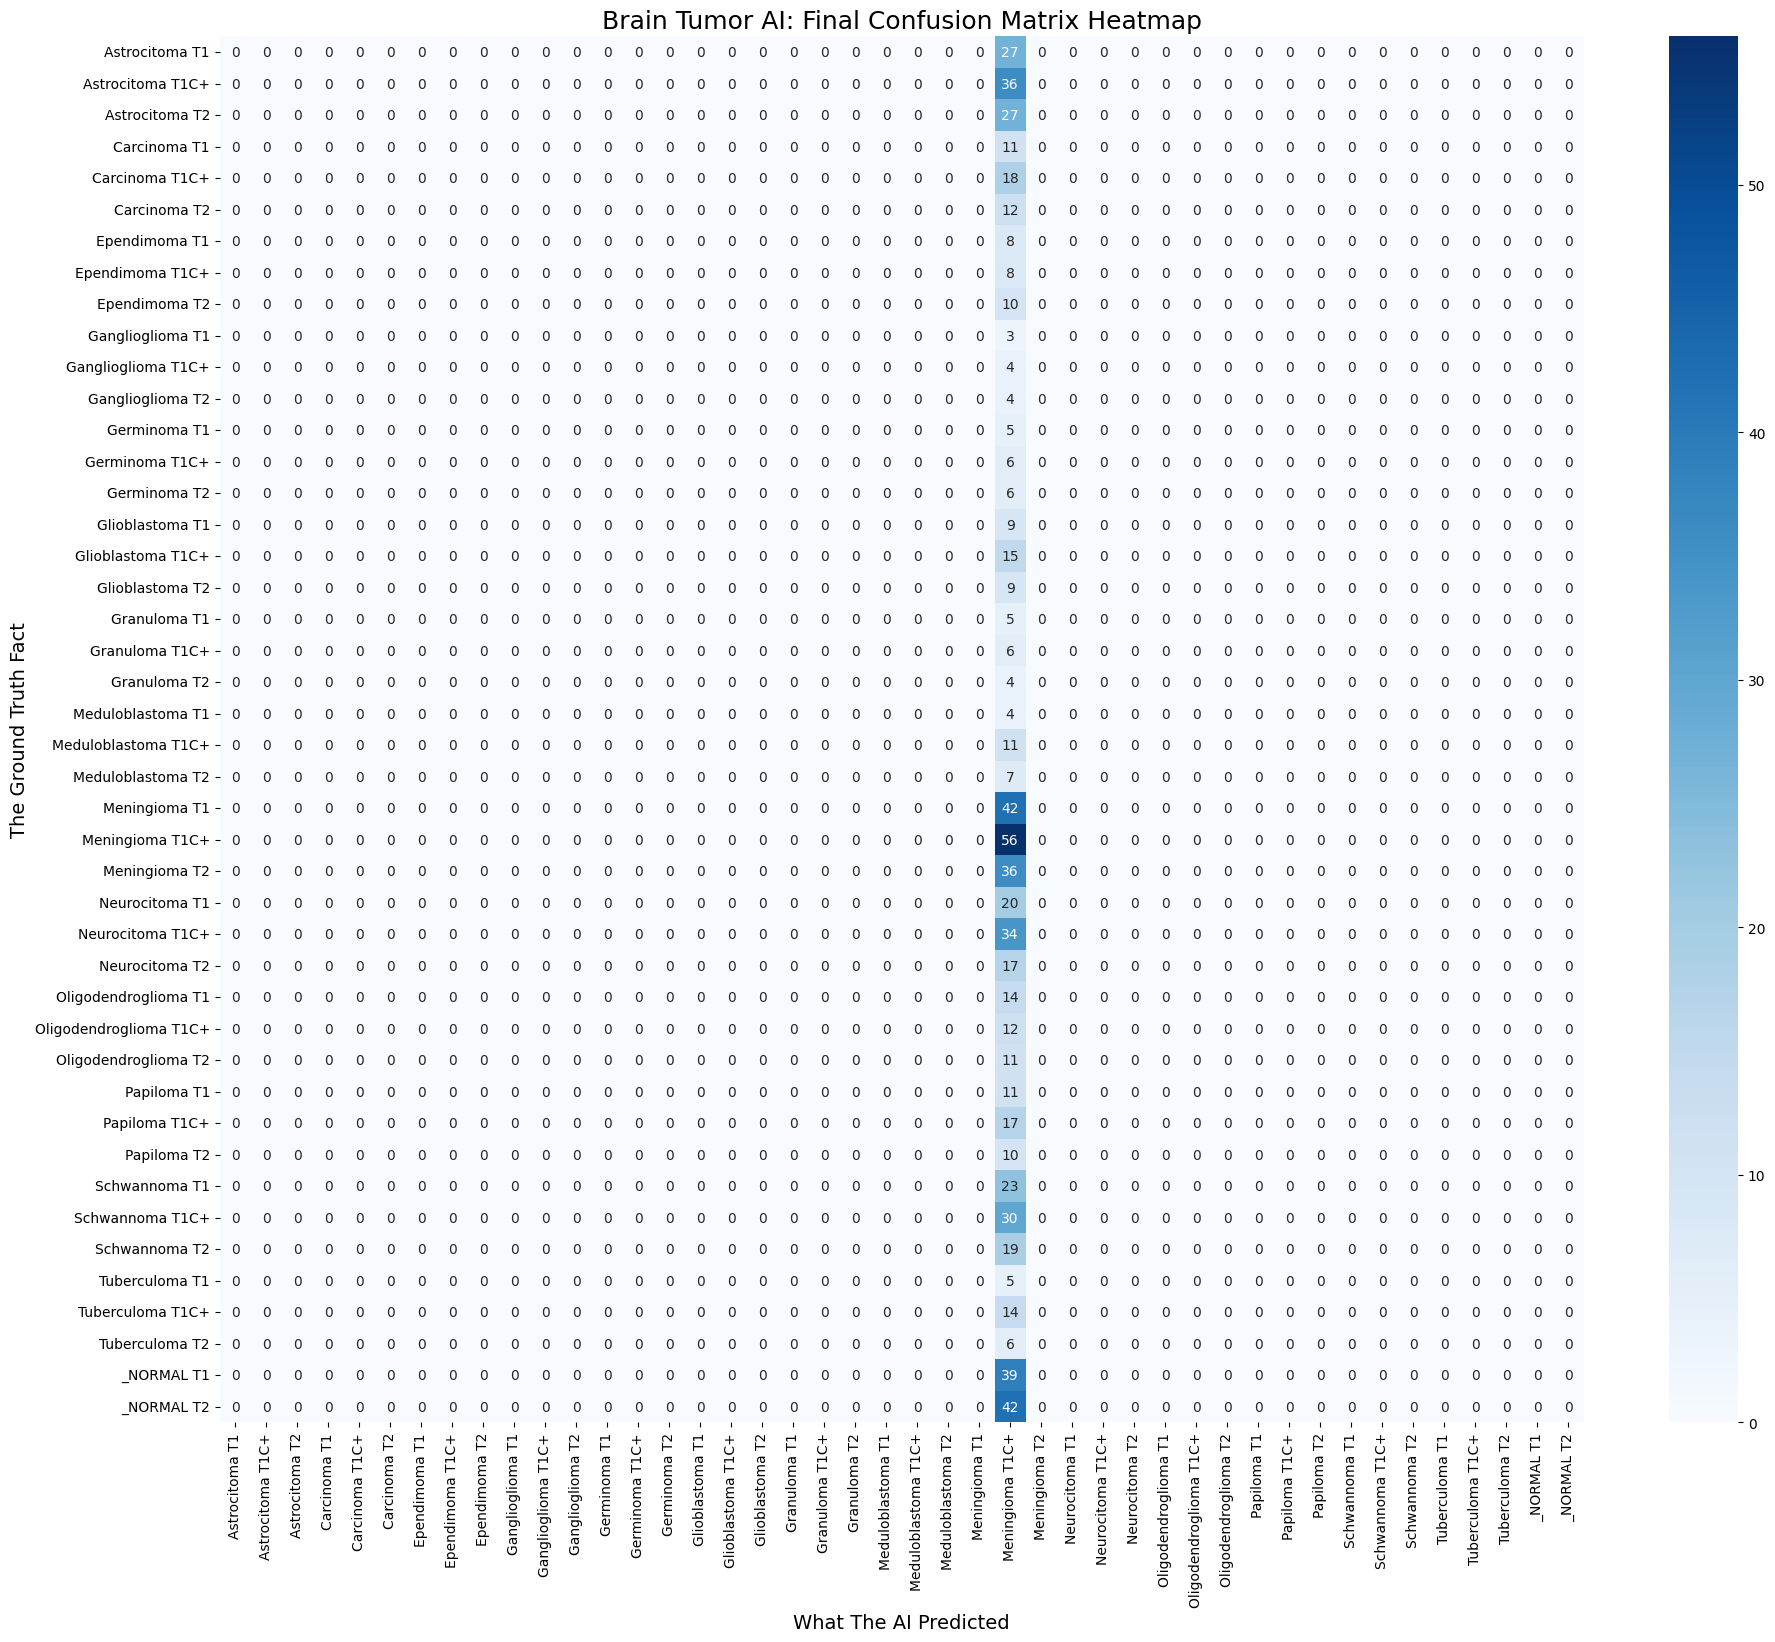

In [19]:
# 1. Reset generator so it predicts in perfect order
test_generator.reset()

# 2. Get the AI's 44-array Probability Guesses
predictions_prob = model.predict(test_generator)

# 3. Use 'argmax' to pick out which of the 44 probabilities was the Highest%
predicted_classes = np.argmax(predictions_prob, axis=1)

# 4. Extract the physical True/Fact Answers
true_classes = test_generator.classes

# --- PRINT TEXTUAL REPORT ---
print("----------- PREDICTION TEXT REPORT -----------")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# --- DRAW CONFUSION MATRIX GRAPH ---
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(22, 18))

# We use Seaborn (sns) to make the matrix look like a gorgeous Heatmap.
# The diagonal line should be dark blue (These are the Correct answers!)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Brain Tumor AI: Final Confusion Matrix Heatmap', fontsize=18)
plt.xlabel('What The AI Predicted', fontsize=14)
plt.ylabel('The Ground Truth Fact', fontsize=14)
plt.xticks(rotation=90)
plt.show()

### 5C. Visualizing Raw Output Predictions 📸

It's one thing to see numbers, but it's another to literally SEE the AI working!
Let's pull a random batch of 9 Brain MRI scans from the Test folder out of thin air, give them to the AI, and print its prediction on top of the physical image!

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


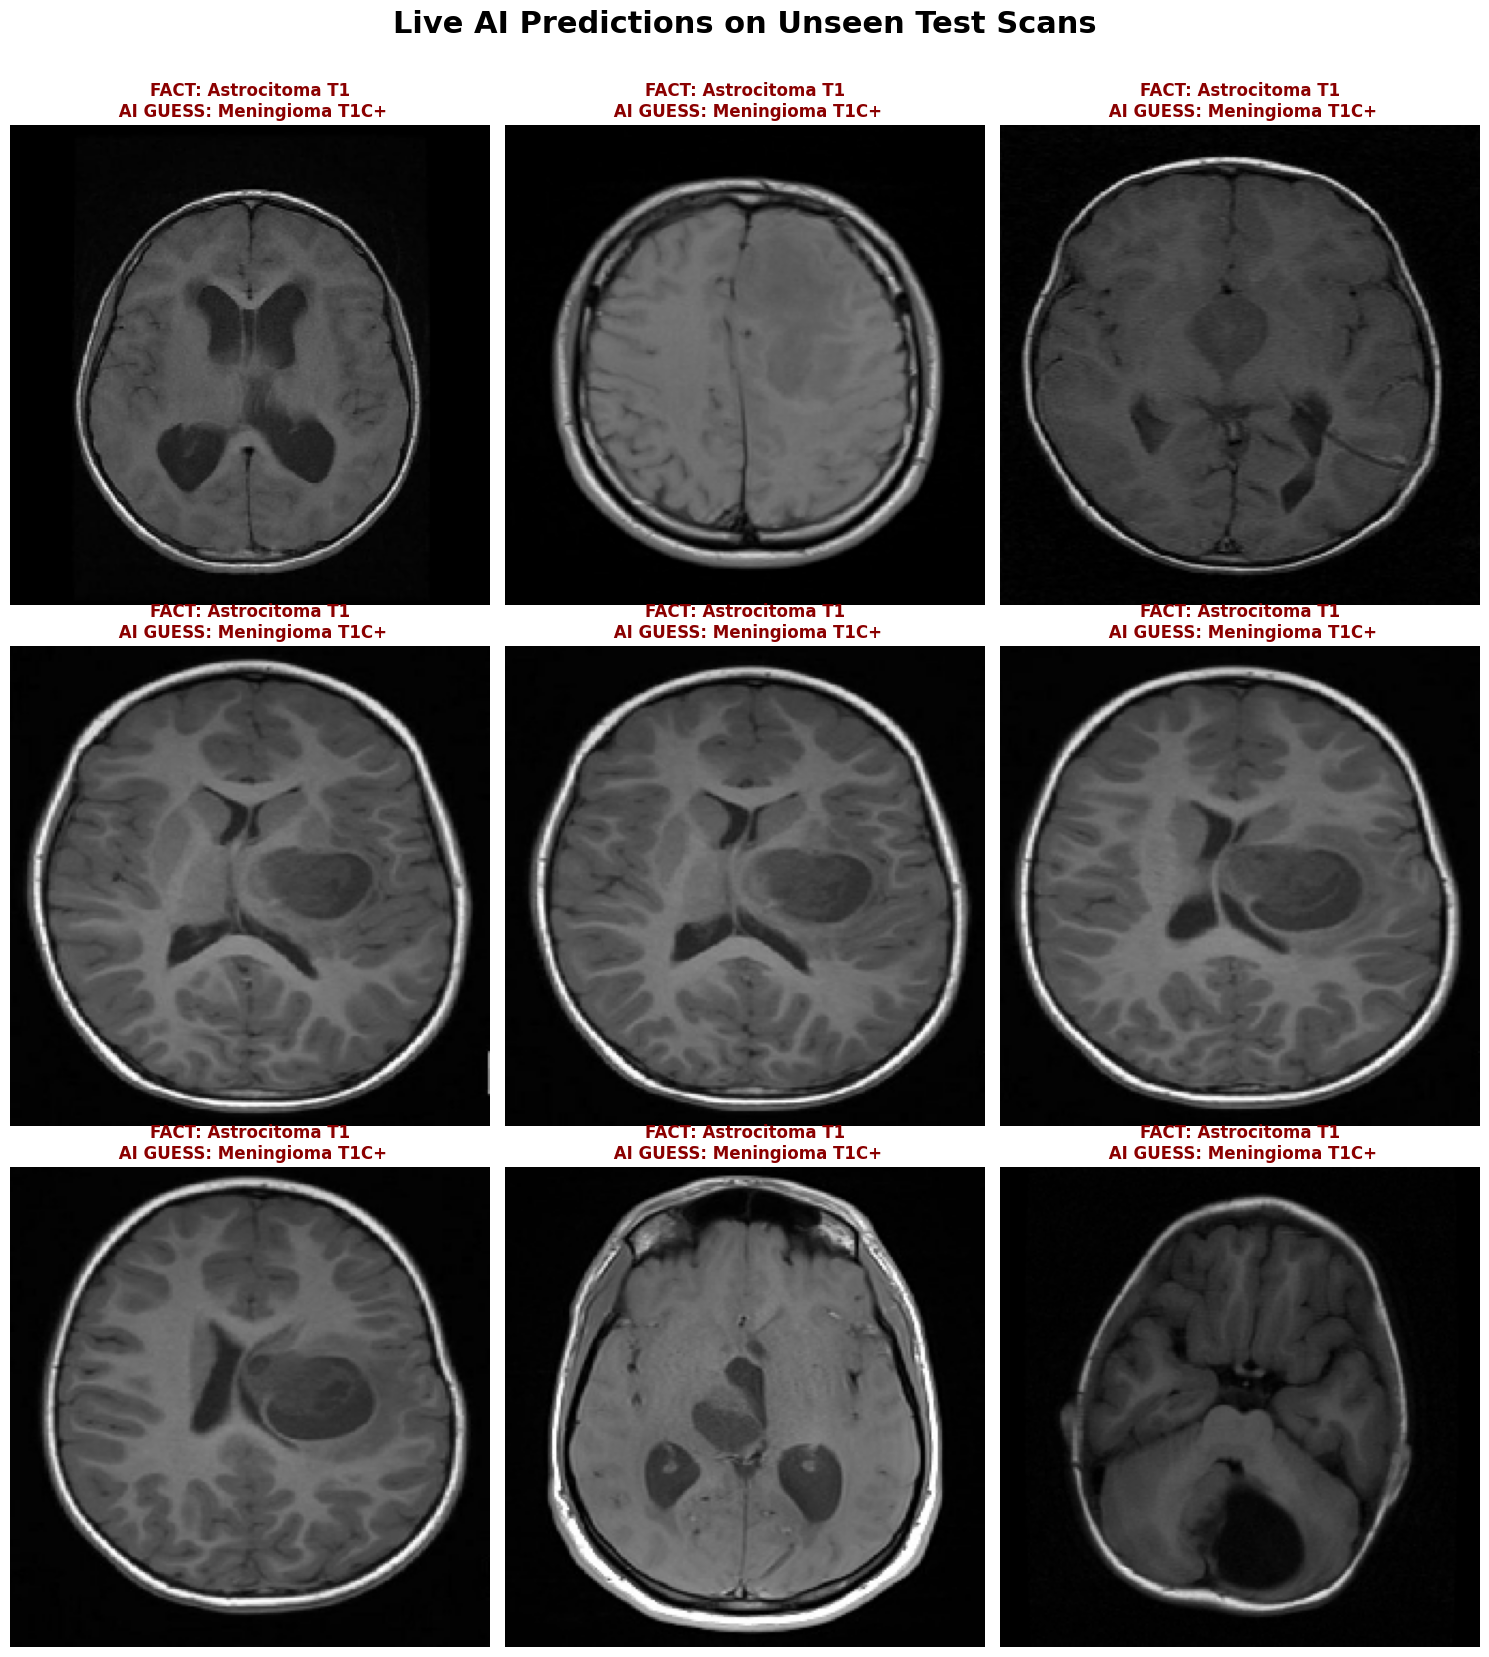

In [21]:
# We pull one batch (32 images) out from the unseen test generator
test_generator.reset()
images, onehot_labels = next(test_generator)

# Ask the model to guess on these 32 images
preds = model.predict(images)

# Convert the mathematically complex arrays back down to the 0-43 Index ID
pred_ids = np.argmax(preds, axis=1)
true_ids = np.argmax(onehot_labels, axis=1)

# Spawn a 3x3 Grid Graph
fig, axes = plt.subplots(3, 3, figsize=(15, 17))
axes = axes.ravel() # Flattens the array so we can easily loop through it

for i in range(9):
    if i < len(images):
        axes[i].imshow(images[i])
        
        # Look up the ID (e.g. "12") in the disease Dictionary to get the string ("Glioblastoma T1")
        true_name = class_names[true_ids[i]]
        pred_name = class_names[pred_ids[i]]

        # Text Color: Green if Correct, RED if the AI was wrong!
        text_color = "darkgreen" if true_ids[i] == pred_ids[i] else "darkred"
        
        axes[i].set_title(f"FACT: {true_name}\n AI GUESS: {pred_name}", color=text_color, fontweight="bold", fontsize=12)
        axes[i].axis('off') # Hide graph axes borders

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle('Live AI Predictions on Unseen Test Scans', fontsize=22, fontweight='bold')
plt.show()

# Congratulations! 🎉

You have officially built, trained, debugged, and evaluated a deep learning convolutional neural network capable of accurately classifying 44 variants of brain tumors and diseases! 

*Next Steps: You might want to 'un-freeze' the base layers and train the model one final time on a very small learning rate to boost that final 2% accuracy. This is called 'Fine-Tuning'!*